# Makemore: Activations, Gradients, BatchNorm

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline
plt.style.use('dark_background')

In [3]:
# Read in all of the words
words = open("../data/names.txt", 'r').read().splitlines()
print(f'First 5 Words: {words[:5]}, length: {len(words)}')

First 5 Words: ['emma', 'olivia', 'ava', 'isabella', 'sophia'], length: 32033


In [4]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(f'itos: {itos}')

itos: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# Function to build a dataset given a list of words

def build_dataset(words):
    block_size = 3 # Context Size
    X, Y = [], []
    
    for word in words:
        context = [0] * block_size

        for c in word + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix] # Crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f'{X.shape=}, {Y.shape=}')
    return X, Y

In [6]:
# Create the trainings splits
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

X.shape=torch.Size([182625, 3]), Y.shape=torch.Size([182625])
X.shape=torch.Size([22655, 3]), Y.shape=torch.Size([22655])
X.shape=torch.Size([22866, 3]), Y.shape=torch.Size([22866])


In [7]:
# MLP Revisited (Hyperparameters)

n_embed = 10        # Dimensionality of the character embedding vectors
n_hidden = 200      # Number of neurons in the hidden layer of MLP
vocab_size = 27     # Fixed by the dataset (26 letters + '.' boundary)
block_size = 3      # Context Length (# chars used to predict next)
seed = 2147483647   # For reproducibility between runs

print(f"Setup: block_size={block_size}, n_embed={n_embed}, n_hidden={n_hidden}")

Setup: block_size=3, n_embed=10, n_hidden=200


In [ ]:
# Initialize parameters from the given seed
gen = torch.Generator().manual_seed(seed)                   # Reproducibility
kaiming = (5 / 3) / ((n_embed * block_size)**0.5)           # Uniformity
lookup = torch.randn((vocab_size, n_embed),                 generator=gen)
weights1 = torch.randn((n_embed * block_size, n_hidden),    generator=gen) * kaiming
biases1 = torch.randn(n_hidden,                             generator=gen) * .01
weights2 = torch.randn((n_hidden, vocab_size),              generator=gen) * .01
biases2 = torch.randn(vocab_size,                           generator=gen) * .01

bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1


parameters = [lookup, weights1, biases1, weights2, biases2, bngain, bnbias]
print(f'Total Parameters: {sum(p.nelement() for p in parameters)}')

for p in parameters:
    p.requires_grad = True 

Total Parameters: 12297


      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


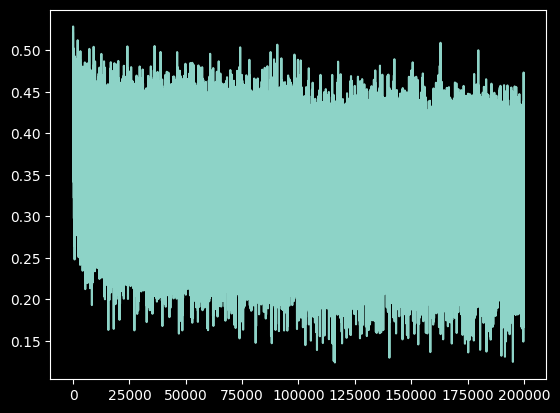

In [9]:
# Optimizations
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=gen)
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X, Y

    # Forward pass
    embed = lookup[Xb] # Embed characters into vectors
    embedcat = embed.view(embed.shape[0], -1) # Concatenate the vectors
    hiddenpre = (embedcat @ weights1) + biases1 # Hidden layer pre-activation

    # Batch Normalization
    mean = hiddenpre.mean(0, keepdim=True)
    std = hiddenpre.std(0, keepdim=True)
    hiddenpre = bngain * (hiddenpre - mean) / std + bnbias

    # Track Batch Normalization Stats (janky)
    with torch.no_grad():
        bnmeans = 0.999 * bnmeans + 0.001 * mean
        bnstds = 0.999 * bnstds + 0.001 * std

    hidden = torch.tanh(hiddenpre) # Hidden layer
    logits = hidden @ weights2 + biases2 # Output layer
    loss = F.cross_entropy(logits, Yb) # Loss function

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update with stepped LR
    lr = 0.1 if i < max_steps / 2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track loss every 100 steps to keep the lossi list small
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(lossi)

In [10]:
# Calibrate the batch norm at the end of training (not necessary)

with torch.no_grad():
    # Pass the training set through
    embed = lookup[Xtr]
    embedcat = embed.view(embed.shape[0], -1)
    hiddenpre = embedcat @ weights1 + biases1

    # Measure the mean/std over the entire training set
    bnmean = hiddenpre.mean(0, keepdim=True)
    bnstd = hiddenpre.std(0, keepdim=True)

print(f'Batch Normalization Mean: \n{bnmean}\n')
print(f'Batch Normalization STD: \n{bnstd}\n')

Batch Normalization Mean: 
tensor([[-2.3355,  0.6776, -0.9133,  1.0163,  1.0865,  1.0938,  1.7437, -2.1208,
          0.5730,  1.4455, -1.6343, -2.7372, -0.4752, -0.1412, -0.0745, -1.1722,
          0.6851, -2.6218, -0.1065,  1.6325, -0.7706, -0.3063,  0.0479,  0.6115,
          1.1173,  0.2427,  2.0500,  0.5831,  0.8527,  1.7680, -0.3625, -0.8355,
         -0.0854, -0.5177, -0.3806, -1.0699, -0.0786,  0.3487, -0.5808,  0.9875,
         -0.4427, -1.3082, -0.2871, -0.2332,  0.6850,  0.6850,  2.0857, -0.7608,
          2.3866,  1.8734,  0.8259,  0.2803,  1.8897,  0.4709,  0.6739, -1.8940,
         -0.0401,  0.4338,  1.3760, -0.8910, -0.4523,  1.1754,  0.5613,  0.6051,
          1.5858,  1.2261, -1.0111,  2.1495, -0.6392,  0.0938, -0.2864, -0.4856,
          0.9632, -1.0461, -2.9990,  0.6391,  1.4327, -0.1590,  0.0941,  0.5253,
          0.2508,  1.2521,  2.0388,  0.6608,  0.0691, -0.0813, -1.6723,  0.2933,
          2.2423, -0.0210, -0.6666,  1.4253, -0.8412, -1.2248, -1.0128,  0.2230,
 

In [11]:
@torch.no_grad() # Disabled gradient tracking
def split_loss(split):
    x,y = {
        'train': {Xtr, Ytr},
        'val': {Xdev, Ydev},
        'test': {Xte, Yte},
    }[split]
    embed = lookup[x] # N, block_size, n_embed
    embedcat = embed.view(embed.shape[0], -1) # concat into (N, block_size, n_embed)
    hiddenpre = (embedcat @ weights1) + biases1 # Hidden layer pre-activation
    
    # Batch Normalization
    hiddenpre = bngain * (hiddenpre - bnmeans) / bnstds + bnbias
    
    hidden = torch.tanh(hiddenpre) # (N, n_hidden)
    logits = hidden @ weights2 + biases2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.06659197807312
val 2.1050572395324707


## Loss Log

### Original
Train:  2.12453
Val:    2.16819

### Fix Softmax Confidently Wrong
Train:  2.07
Val:    2.13

### Fix Tanh Layer Too Saturated @ Init
Train:  2.03559
Val:    2.10267

### Batch Normalization
Train:  2.06669
Val:    2.10481

In [12]:
# Sample from the model
gen = torch.Generator().manual_seed(seed + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # Initialize with all
    
    while True:
        # Forward pass
        embed = lookup[torch.tensor([context])]
        hidden = torch.tanh(embed.view(1, -1) @ weights1 + biases1)
        logits = hidden @ weights2 + biases2
        probabilities = F.softmax(logits, dim=1)

        # Sample from the distribution
        ix = torch.multinomial(probabilities, num_samples=1, generator=gen).item()

        # Shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # If we sample '.': break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # Decode and print the generated word

carpahzarbriq.
shlimrixtts.
lusslaysierricnenddhn.
frtivgqliyah.
farrichaiirdnsleggyu.
bmanvitte.
sants.
lustvi.
vabbuwatth.
giidryxiidh.
sulipsables.
falia.
gtas.
jasfaylahas.
bduricsydustquovozswy.
bjumillassannyks.
sadlusoffordst.
sramsryndlycpllmanraq.
shelseombriyabhda.
ffxrdustvebndvi.


## PyTorch Implementation

In [28]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=gen) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

    
class BatchNorm1D:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Parameters (trained with backpropogation)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):

        # Calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # Normalize to unit variance
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        
        # Update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [29]:
# Hyperparameters

n_embed = 10            # The dimensionality of the character embedding vectors
n_hidden = 100          # The number of neurons in the hidden layer of the MLP
seed = 2147483647
gen = torch.Generator().manual_seed(seed)

lookup = torch.randn((vocab_size, n_embed))
layers = [
    Linear(n_embed * block_size, n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(            n_hidden, n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(            n_hidden, n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(            n_hidden, n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(            n_hidden, n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(            n_hidden, vocab_size), BatchNorm1D(vocab_size), 
]

with torch.no_grad():
    # Last Layer: make less confident
    layers[-1].gamma *= 0.1

    # All other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [lookup] + [parameter for layer in layers for parameter in layer.parameters()]
print(f'# of Total Parameters: {sum(parameter.nelement() for parameter in parameters)}')
for parameter in parameters:
    parameter.requires_grad = True

# of Total Parameters: 47551


In [30]:
# Same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # Minibatch Construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=gen)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward Pass
    embed = lookup[Xb]
    x = embed.view(embed.shape[0], -1)

    # Calculate Loss
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Backward Pass
    # for layer in layers:
        # layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad()
    for parameter in parameters:
        parameter.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < max_steps / 2 else 0.01
    for parameter in parameters:
        parameter.data += -lr * parameter.grad
    
    # Track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    # if i > 1000:
        # break # AFTER_DEBUG: would take out retain_grad()

      0/ 200000: 3.2922
  10000/ 200000: 1.9985
  20000/ 200000: 2.6676
  30000/ 200000: 2.2841
  40000/ 200000: 2.0003
  50000/ 200000: 2.0101
  60000/ 200000: 1.8080
  70000/ 200000: 1.7890
  80000/ 200000: 2.0686
  90000/ 200000: 1.8375
 100000/ 200000: 2.4123
 110000/ 200000: 2.1462
 120000/ 200000: 2.3160
 130000/ 200000: 2.3238
 140000/ 200000: 1.7827
 150000/ 200000: 1.8263
 160000/ 200000: 2.2570
 170000/ 200000: 2.3537
 180000/ 200000: 2.1560
 190000/ 200000: 2.3712


Layer 2 (      Tanh): mean +0.00, std 0.63, saturated: 2.69%
Layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 2.75%
Layer 8 (      Tanh): mean -0.01, std 0.64, saturated: 2.22%
Layer 11 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%
Layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 2.06%


Text(0.5, 1.0, 'Activation Distribution')

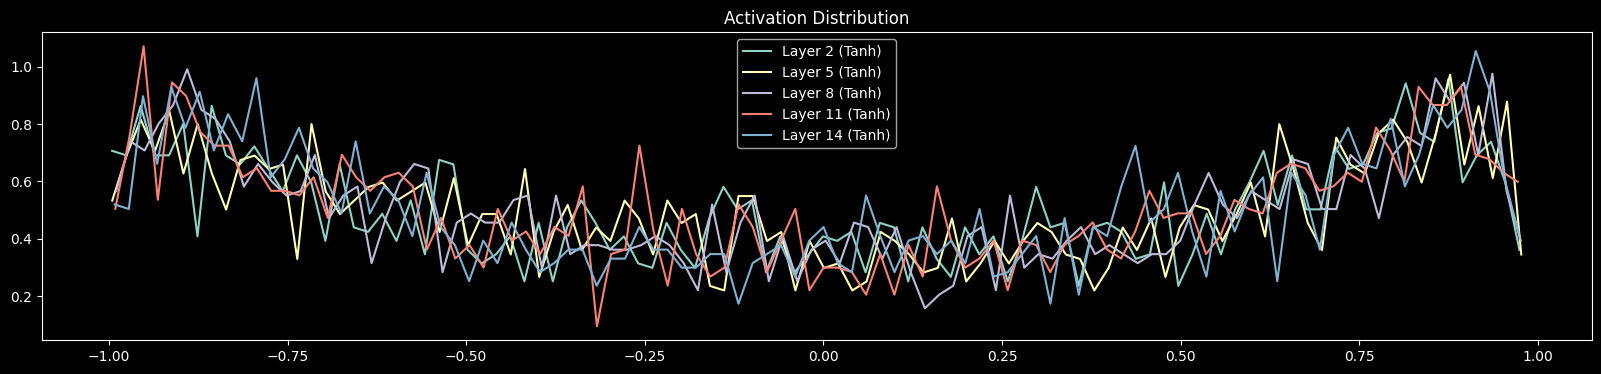

In [24]:
# Visualize Histograms
plt.figure(figsize=(20, 4)) # width and height of plot
legends = []
for i, layer in enumerate(layers[:-1]): # Exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('Layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Activation Distribution')

Layer 2 (      Tanh): mean +0.000000, std 2.795057e-03
Layer 5 (      Tanh): mean +0.000000, std 2.455189e-03
Layer 8 (      Tanh): mean -0.000000, std 2.313169e-03
Layer 11 (      Tanh): mean +0.000000, std 2.245730e-03
Layer 14 (      Tanh): mean +0.000000, std 2.179490e-03


Text(0.5, 1.0, 'Gradient Distribution')

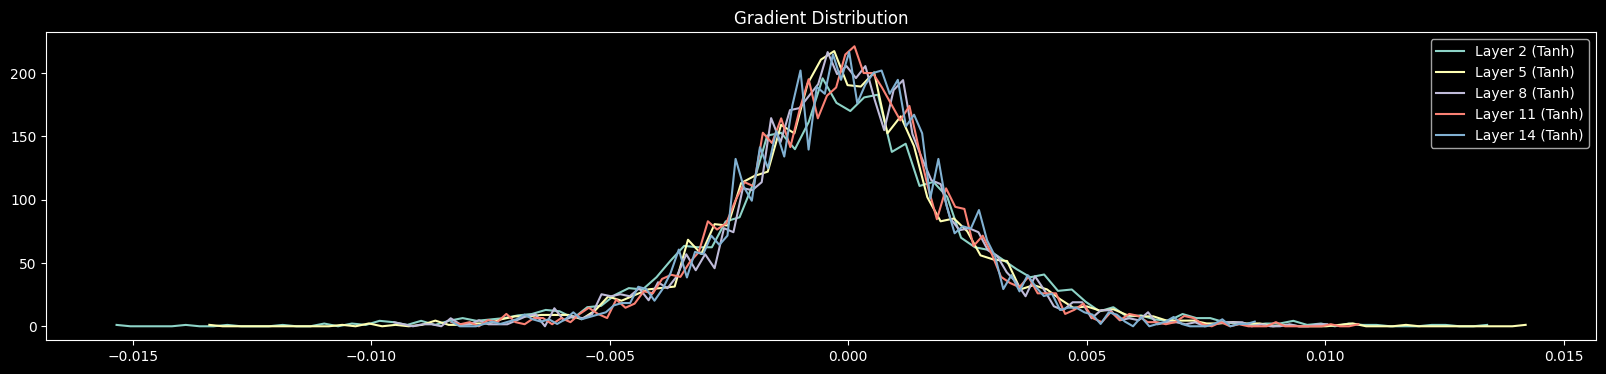

In [25]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('Layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Gradient Distribution')       

weight   (27, 10) | mean -0.000000 | std 7.962505e-03 | grad:data ratio 7.663240e-03
weight  (30, 100) | mean -0.000143 | std 6.979679e-03 | grad:data ratio 2.262883e-02
weight (100, 100) | mean +0.000004 | std 6.179195e-03 | grad:data ratio 3.672502e-02
weight (100, 100) | mean +0.000041 | std 5.310085e-03 | grad:data ratio 3.170071e-02
weight (100, 100) | mean -0.000038 | std 4.716788e-03 | grad:data ratio 2.812368e-02
weight (100, 100) | mean -0.000012 | std 4.338353e-03 | grad:data ratio 2.571343e-02
weight  (100, 27) | mean -0.000083 | std 7.460288e-03 | grad:data ratio 4.479239e-02


Text(0.5, 1.0, 'Weights Gradient Distribution')

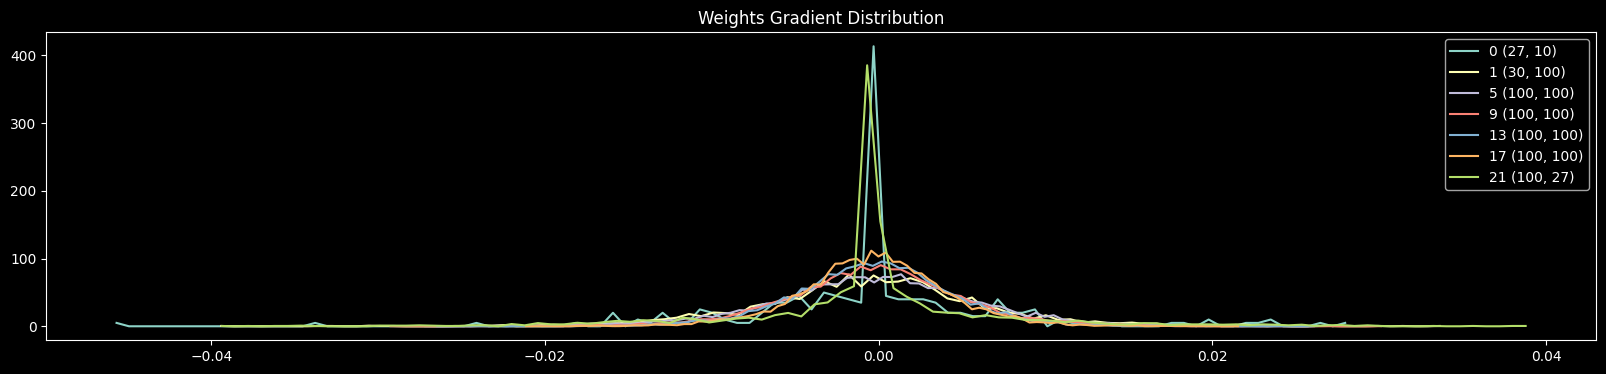

In [26]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights Gradient Distribution')              

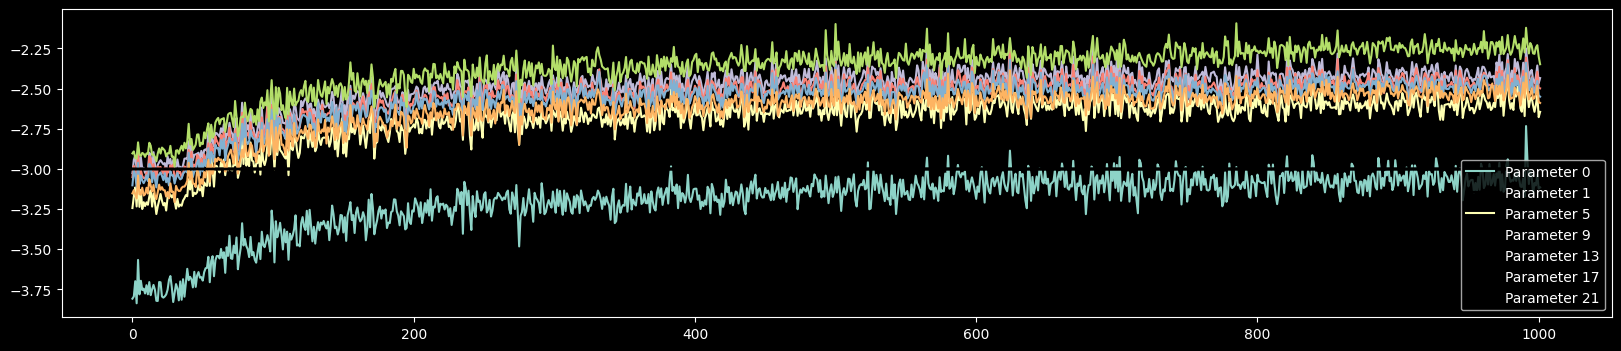

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('Parameter %d' % i)
    plt.plot([0, len(ud)], [-3, -3], 'k')
    plt.legend(legends)